In [3]:
import os, glob, warnings, random, shutil
import numpy as np
import pandas as pd
from tqdm import tqdm
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, f1_score,
    accuracy_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from scipy.stats import iqr

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('✅ Imports done')


# ── Cell 3: File paths ────────────────────────────────────────────────────────
BASE_PATH = "/content/"

ALL_FILES = [
    BASE_PATH + "Monday-WorkingHours.pcap_ISCX.csv",
    BASE_PATH + "Tuesday-WorkingHours.pcap_ISCX.csv",
    BASE_PATH + "Wednesday-workingHours.pcap_ISCX.csv",
    BASE_PATH + "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    BASE_PATH + "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    BASE_PATH + "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    BASE_PATH + "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    BASE_PATH + "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

CHUNK_SIZE = 100_000
print(f"Total files: {len(ALL_FILES)}")


# ── Cell 4: Feature engineering helpers ──────────────────────────────────────
DROP_COLS = ['Flow ID', 'Source IP', 'Destination IP',
             'Source Port', 'Destination Port', 'Timestamp']

# Will be populated after the train/val/test split — from TRAIN ONLY
NEAR_ZERO_VARIANCE_COLS: list = []


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Pure function — no side effects, safe to call on any subset."""
    eps = 1e-8
    df = df.copy()
    if 'Total Fwd Packets' in df.columns and 'Total Backward Packets' in df.columns:
        df['fwd_bwd_pkt_ratio'] = df['Total Fwd Packets'] / (df['Total Backward Packets'] + eps)
    if 'Total Length of Fwd Packets' in df.columns and 'Total Length of Bwd Packets' in df.columns:
        df['fwd_bwd_byte_ratio'] = df['Total Length of Fwd Packets'] / (df['Total Length of Bwd Packets'] + eps)
    for col in ['Flow Duration', 'Total Length of Fwd Packets',
                'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s']:
        if col in df.columns:
            df[f'log1p_{col.replace("/","_per_")}'] = np.log1p(np.clip(df[col].values, 0, None))
    if 'Packet Length Mean' in df.columns and 'Packet Length Std' in df.columns:
        df['pkt_len_cv'] = df['Packet Length Std'] / (df['Packet Length Mean'] + eps)
    if 'Active Mean' in df.columns and 'Idle Mean' in df.columns:
        df['active_idle_ratio'] = df['Active Mean'] / (df['Idle Mean'] + eps)
    if 'PSH Flag Count' in df.columns and 'Total Fwd Packets' in df.columns:
        df['psh_urg_density'] = (
            df.get('PSH Flag Count', 0) + df.get('URG Flag Count', 0)
        ) / (df['Total Fwd Packets'] + eps)
    return df


def clean_chunk(chunk: pd.DataFrame, drop_nzv_cols: list = None):
    """
    Returns (X_df, y_binary_series, y_label_series) — indices reset.
    drop_nzv_cols must be derived from the TRAIN fold only.
    """
    chunk = chunk.copy()
    chunk.columns = chunk.columns.str.strip()
    chunk.drop(columns=[c for c in DROP_COLS if c in chunk.columns], inplace=True)
    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
    chunk['Label'] = chunk['Label'].str.strip()
    y_binary      = (chunk['Label'] != 'BENIGN').astype(int)
    y_attack_label = chunk['Label'].copy()
    X = chunk.drop(columns=['Label'])
    X = X.apply(pd.to_numeric, errors='coerce')
    if drop_nzv_cols:
        X.drop(columns=[c for c in drop_nzv_cols if c in X.columns], inplace=True)
    mask = X.notna().all(axis=1)
    X = X[mask]; y_binary = y_binary[mask]; y_attack_label = y_attack_label[mask]
    X = add_engineered_features(X)
    X.fillna(0, inplace=True)
    return (X.reset_index(drop=True),
            y_binary.reset_index(drop=True),
            y_attack_label.reset_index(drop=True))


print('✅ Feature helpers defined')


# ── Cell 5: Load ALL raw data + SPLIT FIRST ───────────────────────────────────
#
#  KEY FIX: We perform the stratified train/val/test split on RAW DATA
#  before fitting any preprocessing artifact. Nothing — scaler, NZV,
#  IF, AE, score stats — will ever see val or test samples during fitting.
#
print('Loading all raw data (no preprocessing yet)...')
all_X_dfs, all_y_bin, all_y_lbl = [], [], []

for fpath in ALL_FILES:
    print(' >', fpath.split('/')[-1])
    for chunk in tqdm(pd.read_csv(fpath, chunksize=CHUNK_SIZE, low_memory=False)):
        # Drop meta columns + handle inf/nan but do NOT scale yet
        X, y_bin, y_lbl = clean_chunk(chunk, drop_nzv_cols=None)
        if len(X) == 0:
            continue
        all_X_dfs.append(X)
        all_y_bin.append(y_bin)
        all_y_lbl.append(y_lbl)

X_raw_df   = pd.concat(all_X_dfs, ignore_index=True)
y_all_bin  = pd.concat(all_y_bin,  ignore_index=True).values
y_all_lbl  = pd.concat(all_y_lbl,  ignore_index=True).values

# Derive feature columns from ALL files (fix v4 bug: only used first 2 files)
ALL_FEATURE_COLS = list(X_raw_df.columns)
print(f'\nFull dataset: {X_raw_df.shape}')
print(f'Attack rate : {y_all_bin.mean():.3%}')
print('\nLabel distribution:')
for lbl, cnt in pd.Series(y_all_lbl).value_counts().items():
    print(f'  {lbl:50s} {cnt:>8,}')


# ── Cell 6: STRATIFIED SPLIT (raw feature space, no leakage) ─────────────────
# 70% train | 15% val | 15% test — stratify by binary label
X_raw     = X_raw_df.values.astype(np.float32)
del X_raw_df, all_X_dfs   # free RAM

X_tr_raw, X_tmp_raw, y_bin_tr, y_bin_tmp, y_lbl_tr, y_lbl_tmp = train_test_split(
    X_raw, y_all_bin, y_all_lbl,
    test_size=0.30, stratify=y_all_bin, random_state=SEED)

X_val_raw, X_test_raw, y_bin_val, y_bin_test, y_lbl_val, y_lbl_test = train_test_split(
    X_tmp_raw, y_bin_tmp, y_lbl_tmp,
    test_size=0.50, stratify=y_bin_tmp, random_state=SEED)

del X_tmp_raw, y_bin_tmp, y_lbl_tmp

print(f'Train : {X_tr_raw.shape}  attack {y_bin_tr.mean():.3%}')
print(f'Val   : {X_val_raw.shape}  attack {y_bin_val.mean():.3%}')
print(f'Test  : {X_test_raw.shape}  attack {y_bin_test.mean():.3%}')


# ── Cell 7: Fit NZV detection on TRAIN ONLY ───────────────────────────────────
print('\nDetecting near-zero-variance columns on TRAIN fold only...')
X_tr_df = pd.DataFrame(X_tr_raw, columns=ALL_FEATURE_COLS)
stds = X_tr_df.std()
NEAR_ZERO_VARIANCE_COLS = stds[stds < 1e-4].index.tolist()
print(f'  NZV cols to drop: {NEAR_ZERO_VARIANCE_COLS}')

# Drop NZV from all three splits
def drop_nzv(arr, cols_all, nzv):
    keep_idx = [i for i, c in enumerate(cols_all) if c not in nzv]
    return arr[:, keep_idx]

FEATURE_COLS_KEPT = [c for c in ALL_FEATURE_COLS if c not in NEAR_ZERO_VARIANCE_COLS]

X_tr_raw   = drop_nzv(X_tr_raw,   ALL_FEATURE_COLS, NEAR_ZERO_VARIANCE_COLS)
X_val_raw  = drop_nzv(X_val_raw,  ALL_FEATURE_COLS, NEAR_ZERO_VARIANCE_COLS)
X_test_raw = drop_nzv(X_test_raw, ALL_FEATURE_COLS, NEAR_ZERO_VARIANCE_COLS)

joblib.dump(NEAR_ZERO_VARIANCE_COLS, 'nzv_cols.pkl')
joblib.dump(FEATURE_COLS_KEPT, 'feature_cols.pkl')
print(f'Features after NZV drop: {len(FEATURE_COLS_KEPT)}')


# ── Cell 8: Fit scaler on TRAIN ONLY — apply to all three splits ─────────────
#
#  KEY FIX: scaler.fit() only on X_tr_raw.
#  Clip is stored as a stateless transformer so the full pipeline
#  (scaler → clip) can be saved and re-applied identically at inference.
#
print('\nFitting StandardScaler on TRAIN fold only...')
scaler = StandardScaler()
scaler.fit(X_tr_raw)


class ClipTransformer(BaseEstimator, TransformerMixin):
    """Stateless [-10, 10] clip — so the clip is part of the saved pipeline."""
    def __init__(self, lo=-10.0, hi=10.0):
        self.lo = lo
        self.hi = hi
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return np.clip(X, self.lo, self.hi).astype(np.float32)


preprocess_pipeline = Pipeline([
    ('scaler', scaler),
    ('clip',   ClipTransformer()),
])

X_tr_sc   = preprocess_pipeline.transform(X_tr_raw)
X_val_sc  = preprocess_pipeline.transform(X_val_raw)
X_test_sc = preprocess_pipeline.transform(X_test_raw)

# Save the full preprocessing pipeline — one object to load at inference
joblib.dump(preprocess_pipeline, 'preprocess_pipeline.pkl')
print('✅ Preprocessing pipeline saved (scaler + clip)')

del X_tr_raw, X_val_raw, X_test_raw   # free RAM


# ── Cell 9: IsolationForest — fit on TRAIN normal samples only ───────────────
X_tr_normal = X_tr_sc[y_bin_tr == 0]
print(f'\nNormal training samples: {len(X_tr_normal):,}')

MAX_IF = 300_000
idx_if = np.random.choice(len(X_tr_normal), min(MAX_IF, len(X_tr_normal)), replace=False)
X_if   = X_tr_normal[idx_if]

print(f'Training IsolationForest on {len(X_if):,} samples...')
if_model = IsolationForest(n_estimators=300, contamination=0.05,
                            max_samples=256, random_state=SEED, n_jobs=-1)
if_model.fit(X_if)
joblib.dump(if_model, 'isolation_forest.pkl')
print('✅ IsolationForest saved')


# ── Cell 10: Autoencoder — fit on TRAIN normal samples only ──────────────────
def build_autoencoder(dim, latent_dim=32):
    reg = l2(1e-5)
    inp = Input(shape=(dim,), name='input')
    x = Dense(256, activation='relu', kernel_regularizer=reg)(inp)
    x = BatchNormalization()(x); x = Dropout(0.2)(x)
    x = Dense(128, activation='relu', kernel_regularizer=reg)(x)
    x = BatchNormalization()(x); x = Dropout(0.2)(x)
    x = Dense(64,  activation='relu', kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    bottleneck = Dense(latent_dim, activation='relu', name='bottleneck')(x)
    x = Dense(64,  activation='relu', kernel_regularizer=reg)(bottleneck)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu', kernel_regularizer=reg)(x)
    out = Dense(dim, activation='linear', name='output')(x)
    m = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
    return m


n_features = X_tr_sc.shape[1]
ae = build_autoencoder(n_features)
ae.summary()

X_ae_tr, X_ae_val = train_test_split(X_tr_normal, test_size=0.1, random_state=SEED)
callbacks_ae = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, monitor='val_loss')
]

print('Training Autoencoder on normal train samples...')
ae.fit(
    X_ae_tr, X_ae_tr,
    validation_data=(X_ae_val, X_ae_val),
    epochs=60,
    batch_size=2048,
    callbacks=callbacks_ae,
    verbose=1
)

ae.export("autoencoder_savedmodel")
print('✅ Autoencoder exported as SavedModel')


# ── Cell 11: Score normalisation stats — TRAIN fold only ─────────────────────
#
#  KEY FIX: IF and AE scores are computed on X_tr_sc (train scaled).
#  median/IQR computed on training predictions only — no val/test contamination.
#
print('\nComputing IF scores on TRAIN fold...')
if_scores_tr  = -if_model.score_samples(X_tr_sc)

print('Computing AE errors on TRAIN fold...')
ae_preds_tr   = ae.predict(X_tr_sc, batch_size=4096, verbose=1)
ae_errors_tr  = np.mean((X_tr_sc - ae_preds_tr) ** 2, axis=1)

IF_MEDIAN = np.median(if_scores_tr);  IF_IQR = iqr(if_scores_tr) + 1e-8
AE_MEDIAN = np.median(ae_errors_tr);  AE_IQR = iqr(ae_errors_tr) + 1e-8

score_stats = {'if_median': IF_MEDIAN, 'if_iqr': IF_IQR,
               'ae_median': AE_MEDIAN, 'ae_iqr': AE_IQR}
joblib.dump(score_stats, 'score_stats.pkl')
print(f'IF  median={IF_MEDIAN:.4f}  IQR={IF_IQR:.4f}')
print(f'AE  median={AE_MEDIAN:.6f} IQR={AE_IQR:.6f}')


# ── Cell 12: Build hybrid feature matrices ────────────────────────────────────
#
#  Score normalisation uses stats computed on TRAIN only (see Cell 11).
#  No leakage: the same stats are applied to val and test without re-fitting.
#
def build_hybrid(X_scaled: np.ndarray) -> np.ndarray:
    if_sc  = -if_model.score_samples(X_scaled)
    if_n   = (if_sc  - IF_MEDIAN) / IF_IQR
    ae_p   = ae.predict(X_scaled, batch_size=4096, verbose=0)
    ae_err = np.mean((X_scaled - ae_p) ** 2, axis=1)
    ae_n   = (ae_err - AE_MEDIAN) / AE_IQR
    ae_log = np.log1p(ae_err)
    return np.hstack([X_scaled,
                      if_n.reshape(-1, 1),
                      ae_n.reshape(-1, 1),
                      ae_log.reshape(-1, 1)]).astype(np.float32)


print('Building hybrid feature matrices...')
X_tr_h   = build_hybrid(X_tr_sc)
X_val_h  = build_hybrid(X_val_sc)
X_test_h = build_hybrid(X_test_sc)
print(f'Hybrid: train={X_tr_h.shape}  val={X_val_h.shape}  test={X_test_h.shape}')

del X_tr_sc, X_val_sc, X_test_sc   # free RAM


# ── Cell 13: XGBoost Binary Detector ─────────────────────────────────────────
n_neg  = (y_bin_tr == 0).sum()
n_pos  = (y_bin_tr == 1).sum()
ratio  = n_neg / n_pos
print(f'Class ratio {ratio:.1f} → scale_pos_weight')

detector = XGBClassifier(
    n_estimators          = 1200,
    max_depth             = 8,
    learning_rate         = 0.04,
    scale_pos_weight      = ratio,
    subsample             = 0.85,
    colsample_bytree      = 0.75,
    colsample_bylevel     = 0.75,
    min_child_weight      = 3,
    gamma                 = 0.3,
    reg_alpha             = 0.05,
    reg_lambda            = 1.5,
    eval_metric           = 'aucpr',
    early_stopping_rounds = 40,
    random_state          = SEED,
    n_jobs                = -1,
    tree_method           = 'hist',
)

print('Training binary detector...')
detector.fit(
    X_tr_h, y_bin_tr,
    eval_set=[(X_val_h, y_bin_val)],   # val_h used only for early stopping
    verbose=100
)
joblib.dump(detector, 'xgb_detector.pkl')
print(f'✅ Binary detector saved  | best iter: {detector.best_iteration}')


# ── Cell 14: Threshold tuning on VALIDATION set ───────────────────────────────
#
#  Threshold is chosen on val_h — test_h is never touched here.
#
val_probs = detector.predict_proba(X_val_h)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_bin_val, val_probs)

f1_vals     = 2 * precisions * recalls / (precisions + recalls + 1e-8)
# Require recall >= 0.99 to meet the 99% target
recall_mask = recalls[:-1] >= 0.99
if recall_mask.any():
    masked_f1 = np.where(recall_mask, f1_vals[:-1], 0)
    best_idx  = np.argmax(masked_f1)
else:
    best_idx  = np.argmax(f1_vals[:-1])

BEST_THRESHOLD = float(thresholds[best_idx])
joblib.dump(BEST_THRESHOLD, 'best_threshold.pkl')

print(f'Best threshold : {BEST_THRESHOLD:.4f}')
print(f'Val Precision  : {precisions[best_idx]:.4f}')
print(f'Val Recall     : {recalls[best_idx]:.4f}')
print(f'Val F1         : {f1_vals[best_idx]:.4f}')


# ── Cell 15: Evaluate binary detector on TEST set ────────────────────────────
print('\n=== BINARY DETECTION — TEST SET (first and only look) ===')
test_probs = detector.predict_proba(X_test_h)[:, 1]
test_preds = (test_probs >= BEST_THRESHOLD).astype(int)

print(classification_report(y_bin_test, test_preds, target_names=['BENIGN', 'ATTACK']))
acc  = accuracy_score(y_bin_test, test_preds)
prec = precision_score(y_bin_test, test_preds, zero_division=0)
rec  = recall_score(y_bin_test, test_preds, zero_division=0)
f1   = f1_score(y_bin_test, test_preds, zero_division=0)
roc  = roc_auc_score(y_bin_test, test_probs)
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1       : {f1:.4f}')
print(f'ROC-AUC  : {roc:.4f}')

cm = confusion_matrix(y_bin_test, test_preds)
print('\nConfusion Matrix:')
print(pd.DataFrame(cm, index=['BENIGN', 'ATTACK'],
                   columns=['pred_BENIGN', 'pred_ATTACK']))


# ── Cell 16: Stage-2 Attack Type Classifier ───────────────────────────────────
#
#  KEY FIXES:
#  A) Use only TRAIN-fold attacks (X_tr_h where y_bin_tr == 1).
#     Val/test attack samples are kept fully separate.
#  B) Stratified 80/20 split FIRST, THEN SMOTE on the training portion.
#     This prevents synthetic samples from leaking into the held-out test set.
#  C) Internal val for early stopping uses a proper stratified split,
#     not a tail slice which was predominantly synthetic in v4.
#
le = LabelEncoder()
atk_mask_tr = y_bin_tr == 1
le.fit(y_lbl_tr[atk_mask_tr])
print('Attack types in training:')
for i, cls in enumerate(le.classes_):
    cnt = (y_lbl_tr[atk_mask_tr] == cls).sum()
    print(f'  [{i}] {cls:50s}  {cnt:>8,}')

joblib.dump(le, 'attack_label_encoder.pkl')

X_atk_raw = X_tr_h[atk_mask_tr]
y_atk_raw = le.transform(y_lbl_tr[atk_mask_tr])

# ── Stratified 80/20 split BEFORE SMOTE ──────────────────────────────────────
X_atk_tr, X_atk_te, y_atk_tr, y_atk_te = train_test_split(
    X_atk_raw, y_atk_raw,
    test_size=0.20, stratify=y_atk_raw, random_state=SEED)

print(f'\nStage-2 raw train: {len(X_atk_tr):,}  held-out eval: {len(X_atk_te):,}')

# ── SMOTE only on the training portion (X_atk_tr, y_atk_tr) ────────────────
counts_atk = pd.Series(y_atk_tr).value_counts()
print('\nAttack class counts in training before SMOTE:')
print(counts_atk)

smote_strategy = {}
for cls_idx, cnt in counts_atk.items():
    if cnt < 500:
        smote_strategy[cls_idx] = 500

if smote_strategy:
    k = min(5, int(counts_atk[counts_atk < 500].min()) - 1)
    k = max(1, k)
    smote = SMOTE(sampling_strategy=smote_strategy, k_neighbors=k, random_state=SEED)
    print(f'\nApplying SMOTE (k={k}) to TRAIN attacks...')
    X_atk_tr, y_atk_tr = smote.fit_resample(X_atk_tr, y_atk_tr)
    print(f'After SMOTE: {len(X_atk_tr):,} samples')

# ── Stratified internal val for early stopping (from augmented training data) ───
X_atk_fit, X_atk_val, y_atk_fit, y_atk_val = train_test_split(
    X_atk_tr, y_atk_tr,
    test_size=0.10, stratify=y_atk_tr, random_state=SEED)

n_cls = len(le.classes_)

atk_classifier = XGBClassifier(
    n_estimators          = 800,
    max_depth             = 7,
    learning_rate         = 0.04,
    subsample             = 0.85,
    colsample_bytree      = 0.75,
    colsample_bylevel     = 0.75,
    min_child_weight      = 3,
    gamma                 = 0.3,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    objective             = 'multi:softprob',
    num_class             = n_cls,
    eval_metric           = 'mlogloss',
    early_stopping_rounds = 20,
    random_state          = SEED,
    n_jobs                = -1,
    tree_method           = 'hist',
)

print('\nTraining attack-type classifier...')
atk_classifier.fit(
    X_atk_fit, y_atk_fit,
    sample_weight=compute_sample_weight('balanced', y_atk_fit),
    eval_set=[(X_atk_val, y_atk_val)],
    verbose=100,
)
joblib.dump(atk_classifier, 'attack_classifier.pkl')
print(f'✅ Attack classifier saved | best iter: {atk_classifier.best_iteration}')


# ── Cell 17: Evaluate Stage-2 on its held-out split ─────────────────────────
print('\n=== ATTACK TYPE CLASSIFICATION — HELD-OUT EVAL SET ===')
y_pred_atk = atk_classifier.predict(X_atk_te)

print(classification_report(y_atk_te, y_pred_atk,
                             target_names=le.classes_, zero_division=0))

atk_acc = accuracy_score(y_atk_te, y_pred_atk)
atk_f1  = f1_score(y_atk_te, y_pred_atk, average='weighted', zero_division=0)
atk_p   = precision_score(y_atk_te, y_pred_atk, average='weighted', zero_division=0)
atk_r   = recall_score(y_atk_te, y_pred_atk, average='weighted', zero_division=0)
print(f'Accuracy  : {atk_acc:.4f}')
print(f'Precision : {atk_p:.4f}')
print(f'Recall    : {atk_r:.4f}')
print(f'F1        : {atk_f1:.4f}')


# ── Cell 18: End-to-End evaluation on TEST set ───────────────────────────────
print('\n=== END-TO-END PIPELINE — TEST SET ===')

# Stage 1
e2e_probs = detector.predict_proba(X_test_h)[:, 1]
e2e_bin   = (e2e_probs >= BEST_THRESHOLD).astype(int)

# Stage 2 (only on samples detected as attacks)
det_idx     = np.where(e2e_bin == 1)[0]
atk_raw     = atk_classifier.predict(X_test_h[det_idx])
atk_names   = le.inverse_transform(atk_raw)

final_labels = np.array(['BENIGN'] * len(X_test_h), dtype=object)
final_labels[det_idx] = atk_names

e2e_acc = (final_labels == y_lbl_test).mean()
print(f'End-to-End Accuracy : {e2e_acc:.4f}')

print('\nPrediction distribution:')
for lbl, cnt in pd.Series(final_labels).value_counts().items():
    print(f'  {lbl:50s} {cnt:>8,}')

print('\nGround truth distribution:')
for lbl, cnt in pd.Series(y_lbl_test).value_counts().items():
    print(f'  {lbl:50s} {cnt:>8,}')


# ── Cell 19: Save all models to  models/ ─────────────────────────────────────
OUTPUT_DIR = 'models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for fname in [
    'preprocess_pipeline.pkl',   # scaler + clip (replaces scaler.pkl alone)
    'nzv_cols.pkl',
    'score_stats.pkl',
    'isolation_forest.pkl',
    'xgb_detector.pkl',
    'best_threshold.pkl',
    'attack_classifier.pkl',
    'attack_label_encoder.pkl',
    'feature_cols.pkl',
]:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(OUTPUT_DIR, fname))

ae.export(os.path.join(OUTPUT_DIR, 'autoencoder_savedmodel'))
print('✅ Autoencoder exported as SavedModel')
print(f'✅ All models saved to {OUTPUT_DIR}/')
print('Files:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    full = os.path.join(OUTPUT_DIR, f)
    sz = os.path.getsize(full) if os.path.isfile(full) else 0
    print(f'  {f:50s} {sz/1024:.1f} KB')


# ── Cell 20: Final summary ────────────────────────────────────────────────────
print('\n╔══════════════════════════════════════════════════════╗')
print('║          FINAL PERFORMANCE SUMMARY — v5              ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║ STAGE 1 — Binary Detection (test set)               ║')
print(f'║  Accuracy  : {acc:.4f}                              ║')
print(f'║  Precision : {prec:.4f}  (attack class)             ║')
print(f'║  Recall    : {rec:.4f}  (attack class)              ║')
print(f'║  F1-Score  : {f1:.4f}                               ║')
print(f'║  ROC-AUC   : {roc:.4f}                              ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║ STAGE 2 — Attack Type Classification                ║')
print(f'║  Accuracy  : {atk_acc:.4f}                          ║')
print(f'║  Precision : {atk_p:.4f}                            ║')
print(f'║  Recall    : {atk_r:.4f}                            ║')
print(f'║  F1        : {atk_f1:.4f}                           ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║ END-TO-END Accuracy : {e2e_acc:.4f}                 ║')
print('╚══════════════════════════════════════════════════════╝')


# ── Cell 21: Inference usage example (copy to app.py) ────────────────────────
INFERENCE_EXAMPLE = '''
# ─── Correct inference pattern for app.py ────────────────────────────────────
import joblib, numpy as np, pandas as pd
import tensorflow as tf

# Load once at startup
preprocess = joblib.load('models/preprocess_pipeline.pkl')   # scaler + clip
nzv_cols   = joblib.load('models/nzv_cols.pkl')
feat_cols  = joblib.load('models/feature_cols.pkl')
score_stat = joblib.load('models/score_stats.pkl')
if_model   = joblib.load('models/isolation_forest.pkl')
ae         = tf.saved_model.load('models/autoencoder_savedmodel')
detector   = joblib.load('models/xgb_detector.pkl')
threshold  = joblib.load('models/best_threshold.pkl')
le         = joblib.load('models/attack_label_encoder.pkl')
clf2       = joblib.load('models/attack_classifier.pkl')

def predict(raw_df: pd.DataFrame):
    # 1. Feature engineering + drop NZV
    from train_v5 import add_engineered_features, DROP_COLS
    df = raw_df.copy()
    df.columns = df.columns.str.strip()
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
    df = df.apply(pd.to_numeric, errors='coerce')
    df.drop(columns=[c for c in nzv_cols if c in df.columns], inplace=True)
    df = add_engineered_features(df)
    df = df.reindex(columns=feat_cols, fill_value=0).fillna(0)
    X = df.values.astype(np.float32)

    # 2. Scale + clip (single pipeline call — no manual clip needed)
    X_sc = preprocess.transform(X)

    # 3. Hybrid features
    IF_MEDIAN = score_stat['if_median']; IF_IQR = score_stat['if_iqr']
    AE_MEDIAN = score_stat['ae_median']; AE_IQR = score_stat['ae_iqr']
    if_sc  = -if_model.score_samples(X_sc)
    if_n   = (if_sc - IF_MEDIAN) / IF_IQR
    ae_p   = ae.signatures['serving_default'](
                 tf.constant(X_sc))['output_0'].numpy()
    ae_err = np.mean((X_sc - ae_p) ** 2, axis=1)
    ae_n   = (ae_err - AE_MEDIAN) / AE_IQR
    ae_log = np.log1p(ae_err)
    X_h    = np.hstack([X_sc, if_n.reshape(-1,1),
                              ae_n.reshape(-1,1),
                              ae_log.reshape(-1,1)]).astype(np.float32)

    # 4. Stage 1
    probs = detector.predict_proba(X_h)[:, 1]
    preds = (probs >= threshold).astype(int)

    # 5. Stage 2 (attack type) for flagged samples
    labels = np.array(['BENIGN'] * len(X_h), dtype=object)
    atk_idx = np.where(preds == 1)[0]
    if len(atk_idx):
        labels[atk_idx] = le.inverse_transform(clf2.predict(X_h[atk_idx]))

    return labels, probs
'''

with open(os.path.join(OUTPUT_DIR, 'inference_example.py'), 'w') as f:
    f.write(INFERENCE_EXAMPLE)

print('\n✅ inference_example.py written to models/')
print('\n📋 INSTRUCTIONS:')
print('  1. Download the models/ folder from Colab')
print('  2. Copy it to your VS Code project root')
print('  3. pip install flask flask-cors scapy xgboost tensorflow joblib imbalanced-learn')
print('  4. python app.py')
print('  5. Open: http://localhost:5000')

✅ Imports done
Total files: 8
✅ Feature helpers defined
Loading all raw data (no preprocessing yet)...
 > Monday-WorkingHours.pcap_ISCX.csv


6it [00:06,  1.08s/it]


 > Tuesday-WorkingHours.pcap_ISCX.csv


4it [00:04,  1.23s/it]


 > Wednesday-workingHours.pcap_ISCX.csv


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 79)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 79)             │        20,303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,031 (507.93 KB)

 Trainable params: 128,751 (502.93 KB)

 Non-trainable params: 1,280 (5.00 KB)

Training Autoencoder on normal train samples...
Epoch 1/60
565/565 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - loss: 0.0677 - val_loss: 0.0210 - learning_rate: 0.0010
Epoch 2/60
565/565 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0245 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 3/60
565/565 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0190 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 4/60
565/565 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0160 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 5/60
565/565 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0140 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 6/60
565/565 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0125 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 7/60
565/565 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0114 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 8/60
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0105 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 9/60
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0099 - v

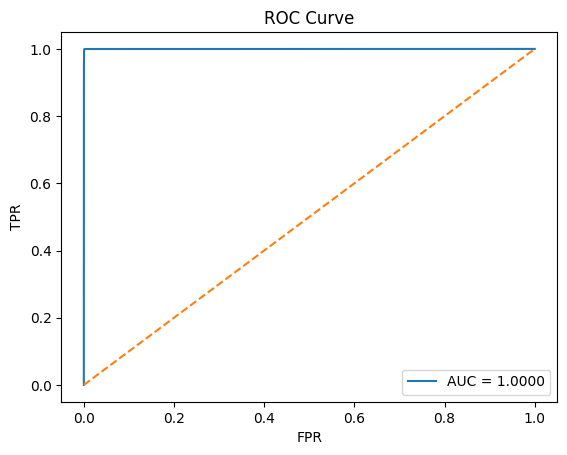

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_bin_test, test_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

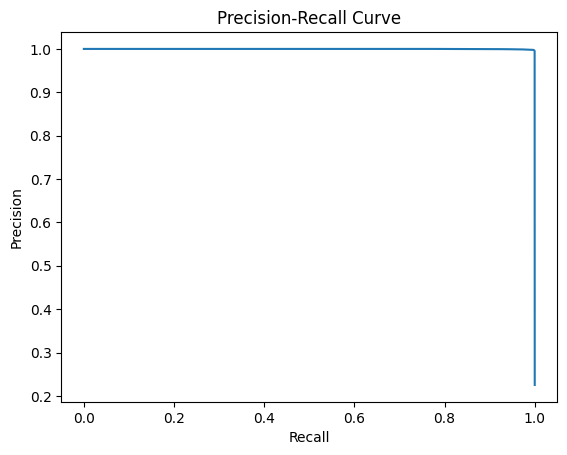

In [5]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_bin_test, test_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

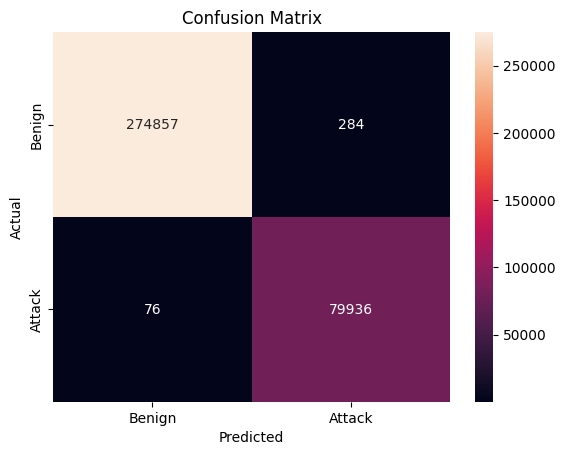

In [6]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Benign','Attack'],
            yticklabels=['Benign','Attack'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
history = ae.fit(
    X_ae_tr, X_ae_tr,
    validation_data=(X_ae_val, X_ae_val),
    epochs=60,
    batch_size=2048,
    callbacks=callbacks_ae,
    verbose=1
)

Epoch 1/60
616/616 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0032 - val_loss: 0.0017 - learning_rate: 1.9531e-06
Epoch 2/60
616/616 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0032 - val_loss: 0.0017 - learning_rate: 1.9531e-06
Epoch 3/60
616/616 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0032 - val_loss: 0.0017 - learning_rate: 1.9531e-06
Epoch 4/60
616/616 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0032 - val_loss: 0.0017 - learning_rate: 1.0000e-06
Epoch 5/60
616/616 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0032 - val_loss: 0.0017 - learning_rate: 1.0000e-06
Epoch 6/60
616/616 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0032 - val_loss: 0.0017 - learning_rate: 1.0000e-06
Epoch 7/60
616/616 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0032 - val_loss: 0.0017 - learning_rate: 1.0000e-06
Epoch 8/60
616/616 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0032 - val_loss: 0.0017 - learning_rate: 1.0000e-06
Epoch 9/60
616/616 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0032 - val_loss: 0.0017 - 

KeyboardInterrupt: 

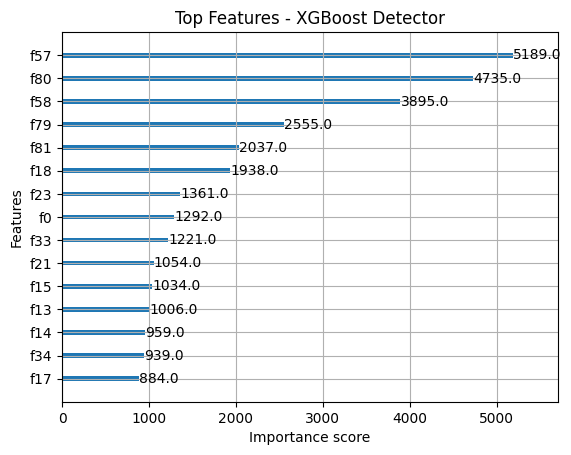

In [ ]:
import xgboost as xgb

xgb.plot_importance(detector, max_num_features=15)
plt.title("Top Features - XGBoost Detector")
plt.show()

In [ ]:
plt.figure()
plt.hist(test_probs[y_bin_test==0], bins=50, alpha=0.5, label='Benign')
plt.hist(test_probs[y_bin_test==1], bins=50, alpha=0.5, label='Attack')
plt.legend()
plt.title("Prediction Score Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

NameError: name 'plt' is not defined

NameError: name 'y_bin_test' is not defined